# データ探索:idsse-data (J03WPY)

現在のパイプライン(`src/pi_fsm/data.py`, `preprocessing.py`)で読み込んでいるトラッキングデータの基本統計量を確認する。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pi_fsm.data import load_match
from pi_fsm.preprocessing import add_velocity, exclude_goalkeepers

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["font.family"] = "Hiragino Sans"  # 日本語タイトル表示用(macOS)

MATCH_ID = "J03WPY"
m = load_match(MATCH_ID)
players = m.players
players.shape

(3216642, 8)

## 基本情報

In [2]:
n_teams = players["team_id"].nunique()
n_players = players["player_id"].nunique()
n_gk = players.loc[players["is_gk"], "player_id"].nunique()
duration_s = players["t"].max() * players["period_id"].nunique()  # rough, per-period

print(f"match_id       : {MATCH_ID}")
print(f"frame_rate     : {m.frame_rate} Hz")
print(f"pitch          : {m.pitch_length} m x {m.pitch_width} m")
print(f"teams          : {n_teams}")
print(f"players        : {n_players} (GK: {n_gk}, outfield: {n_players - n_gk})")
print(f"periods        : {sorted(players['period_id'].unique())}")
print(f"frames/player  : {players.groupby('player_id').size().describe()[['min','mean','max']].to_dict()}")
print(f"rows total     : {len(players):,}")

match_id       : J03WPY
frame_rate     : 25 Hz
pitch          : 105.0 m x 68.0 m
teams          : 2
players        : 31 (GK: 2, outfield: 29)
periods        : [np.int64(1), np.int64(2)]
frames/player  : {'min': 19912.0, 'mean': 103762.64516129032, 'max': 146211.0}
rows total     : 3,216,642


## 座標・データ品質(範囲チェック、欠損)

In [3]:
display(players[["x", "y"]].describe())

# ピッチ範囲外(±0.5m マージン)のフレーム数
out_of_bounds = (
    (players["x"].abs() > m.pitch_length / 2 + 0.5)
    | (players["y"].abs() > m.pitch_width / 2 + 0.5)
)
print(f"pitch外の座標: {out_of_bounds.sum()} / {len(players)} ({out_of_bounds.mean():.4%})")

# フレームの欠損(period内でframe_idが連番でない箇所)
gaps = (
    players.sort_values(["player_id", "period_id", "frame_id"])
    .groupby(["player_id", "period_id"])["frame_id"]
    .apply(lambda s: (s.diff() > 1).sum())
)
print(f"フレーム欠損(選手・ピリオド単位の非連続箇所)合計: {gaps.sum()}")

,x,y
count,3.216642e+06,3.216642e+06
mean,3.455336e-01,-1.035521e+00
std,2.517592e+01,1.474937e+01
min,-5.550000e+01,-3.604000e+01
25%,-1.718000e+01,-1.085000e+01
50%,3.900000e-01,-7.600000e-01
75%,1.894000e+01,8.150000e+00
max,5.550000e+01,3.790000e+01


pitch外の座標: 15705 / 3216642 (0.4882%)


フレーム欠損(選手・ピリオド単位の非連続箇所)合計: 0


## ピッチ上の占有ヒートマップ(全選手・全フレーム)

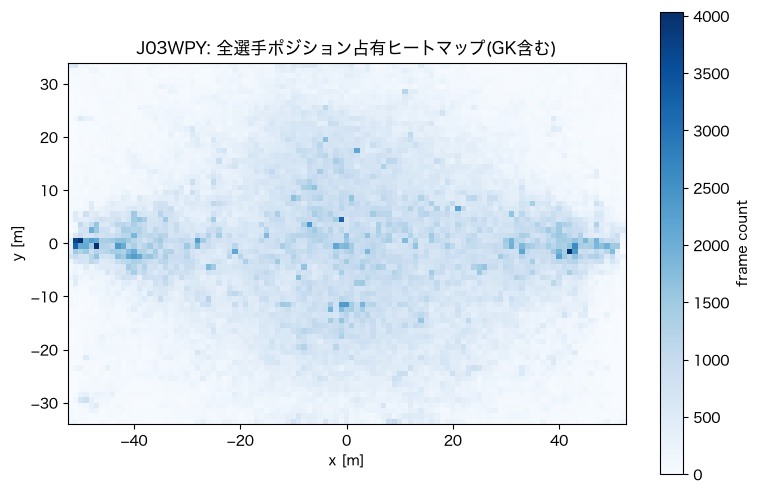

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
h = ax.hist2d(
    players["x"], players["y"],
    bins=[np.linspace(-52.5, 52.5, 106), np.linspace(-34, 34, 69)],
    cmap="Blues",
)
ax.set_xlim(-52.5, 52.5)
ax.set_ylim(-34, 34)
ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(f"{MATCH_ID}: 全選手ポジション占有ヒートマップ(GK含む)")
fig.colorbar(h[3], ax=ax, label="frame count")
plt.show()

## 速度分布(論文Fig.1相当:GK vs フィールドプレーヤー)

速度 $v(t)$ は1秒後退差分(`preprocessing.add_velocity`)。GKは歩行($\simeq$1m/s)のピークのみ、フィールドプレーヤーは歩行+ジョグ($\simeq$3m/s)の2ピークになるはず。

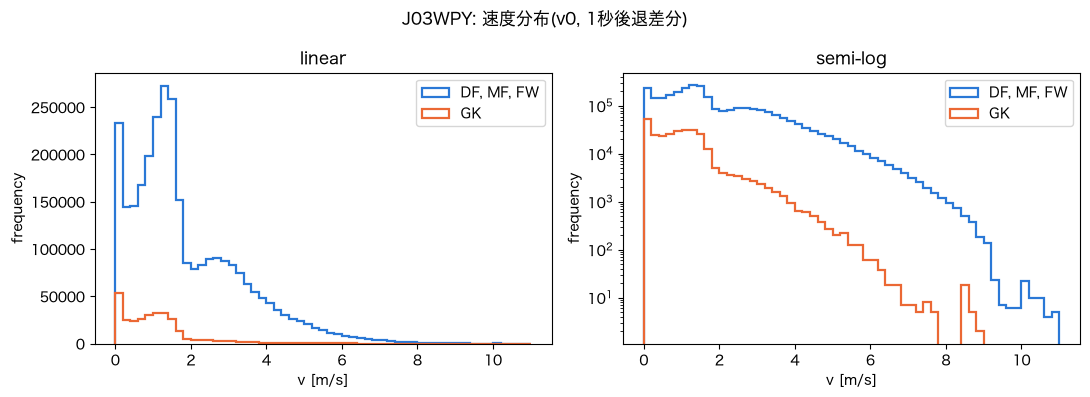

In [5]:
players_v = add_velocity(players, m.frame_rate).dropna(subset=["v0"])
gk = players_v[players_v["is_gk"]]
outfield = players_v[~players_v["is_gk"]]

bins = np.linspace(0, 11, 56)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, log in zip(axes, [False, True]):
    ax.hist(outfield["v0"], bins=bins, histtype="step", label="DF, MF, FW", color="#2a78d6", lw=1.6)
    ax.hist(gk["v0"], bins=bins, histtype="step", label="GK", color="#eb6834", lw=1.6)
    ax.set_xlabel("v [m/s]")
    ax.set_ylabel("frequency")
    if log:
        ax.set_yscale("log")
    ax.legend()

axes[0].set_title("linear")
axes[1].set_title("semi-log")
fig.suptitle(f"{MATCH_ID}: 速度分布(v0, 1秒後退差分)")
fig.tight_layout()
plt.show()

## 選手ごとの要約統計量

In [6]:
per_player = (
    players_v.groupby(["player_id", "is_gk"])
    .agg(
        n_frames=("frame_id", "size"),
        v0_mean=("v0", "mean"),
        v0_max=("v0", "max"),
        v0_p95=("v0", lambda s: s.quantile(0.95)),
    )
    .reset_index()
    .sort_values("v0_max", ascending=False)
)
per_player

,player_id,is_gk,n_frames,v0_mean,v0_max,v0_p95
26,DFL-OBJ-J01CP5,False,50754,1.956409,41.393828,5.081833
24,DFL-OBJ-002GMO,False,146161,1.836350,40.790044,4.405326
22,DFL-OBJ-002GM1,False,31129,2.042762,38.431427,5.385150
7,DFL-OBJ-0001LJ,False,126249,1.842932,38.167174,4.665505
4,DFL-OBJ-0000NZ,False,146161,1.783440,35.341541,4.830093
29,DFL-OBJ-J01KJ5,False,146161,1.866136,32.009200,4.772002
13,DFL-OBJ-0028BZ,False,146161,1.975125,31.681353,5.150582
17,DFL-OBJ-002FYC,False,114517,1.821067,28.990310,4.538594
10,DFL-OBJ-0026IA,False,47830,1.910656,28.382961,4.925814
23,DFL-OBJ-002GM9,False,146161,1.594125,26.863991,4.204343
